## TCG ML PRIMER ##

**Contents:** 

Hello analysts. Below is a practical walkthrough of the full machine learning workflow using the California housing dataset. You will learn how to frame a regression problem, prepare data, engineer features, train models, evaluate performance, and interpret results. 

---

# Table of Contents 
## 1. Problem definition
What we'll do here: frame the business/data question and choose a prediction target and evaluation metric.  
What you'll learn: how to turn a real-world question into a supervised regression task and choose an appropriate metric.
1. predict median_house_value from housing characteristics and location  
2. target: median_house_value, metric: R^2 / MAE / RMSE

---

## 2. Load data & missing values
What we'll do here: load the dataset and quickly summarize missing values so we know how to clean it.  
What you'll learn: practical data loading and basic missing-value checks.
1. dataset loaded with housing features such as location, size, income, and ocean proximity  
2. missing values review and handling strategy

---

## 3. Exploratory Data Analysis (EDA)
What we'll do here: inspect distributions and relationships to spot useful predictors.  
What you'll learn: how to find signal and surface relationships that inform features.
1. inspect distributions for income, age, rooms, and house value  
2. explore categorical patterns by ocean proximity  
3. identify features that look predictive

---

## 4. Data cleaning
What we'll do here: tidy obvious issues, remove duplicates, and handle invalid values.  
What you'll learn: pragmatic cleaning choices that keep useful rows and prepare data for modeling.
1. remove duplicates and filter invalid values  
2. prepare the data for modeling

---

## 5. Feature engineering
What we'll do here: create useful variables from the housing data to improve model performance.  
What you'll learn: simple domain-driven feature creation and transformations.
1. engineered ratio features such as rooms_per_household and bedrooms_per_room  
2. transformed income using a log scale  
3. final feature list: housing_median_age, total_rooms, total_bedrooms, population, households, median_income, rooms_per_household, bedrooms_per_room, population_per_household, log_median_income, ocean_proximity

---

## 6. Preprocessing pipeline
What we'll do here: define consistent transformations for numeric and categorical inputs using sklearn pipelines.  
What you'll learn: why pipelines and ColumnTransformer keep preprocessing reproducible and tidy.
1. numeric: median imputer + StandardScaler  
2. categorical: most frequent imputer + OneHotEncoder (handle_unknown='ignore')  
3. ColumnTransformer + Pipeline usage

---

## 7. Train / test split
What we'll do here: create a held-out test set so we can evaluate the model on unseen data.  
What you'll learn: why a separate test set matters for regression and how to split the data.
1. train/test split on the housing data  
2. y_train / y_test sizes and why we hold out a test set

---

## 8. Model selection & training
What we'll do here: fit several regression models and compare their performance.  
What you'll learn: how to compare different algorithms with the same preprocessing pipeline and evaluation metric.
1. trained and compared: Linear Regression, Decision Tree, Random Forest, Extra Trees, Gradient Boosting, HistGradientBoosting  
2. evaluated using R^2, MAE, and RMSE

---

## 9. Cross-validation results
What we'll do here: summarize cross-validated performance and choose promising candidates to tune.  
What you'll learn: how to read mean/std CV scores and choose models for tuning.
1. CV scores and cv_results_df showing mean/std per model  
2. per-fold scores array

---

## 10. Hyperparameter tuning
What we'll do here: run GridSearchCV on the chosen model to find better hyperparameters.  
What you'll learn: how to set up param grids, use cross-validation, and select the best parameters by the chosen metric.
1. GridSearchCV over RandomForestRegressor parameters  
2. best params -> tuning_pipeline / grid_search

---

## 11. Final model & evaluation
What we'll do here: train the final pipeline with the tuned parameters and evaluate it on the test set.  
What you'll learn: how to report final test metrics and collect predictions for analysis.
1. selected final_model (RandomForest pipeline with tuned params)  
2. test set evaluation: R^2, MAE, RMSE  
3. final_preds / test_preds arrays

---

## 12. Model interpretation & error analysis
What we'll do here: inspect feature importances and review the largest prediction errors to understand model behavior.  
What you'll learn: how to extract actionable insights from importances and analyze errors to guide next steps.
1. feature importances (importance_df / importances)  
2. residual analysis for the largest prediction errors

---

## 13. Next steps / communication
What we'll do here: outline practical recommendations and deployment or validation next steps you can present to a stakeholder.  
What you'll learn: how to convert model results into clear, business-friendly actions and future experiments.
1. explain the model in plain English and discuss next steps  
2. suggestions: richer features, more data, and deployment for future predictions

---

# STEP 0: Imports # 

*These are the imports you should need to complete this primer, you will soon see what each of these is used for and why they are necessary to create a machine learning model*


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    ExtraTreesRegressor
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## STEP 1: Question ##

**Goal:** Use the housing dataset to answer a meaningful business question.

A good question for this dataset could be:

- Can we predict the median house value of a neighborhood from its housing characteristics and location?

This is a supervised regression problem because the target variable, median_house_value, is continuous rather than categorical.

The columns that are likely to be useful for this task include:

- housing_median_age
- total_rooms
- total_bedrooms
- population
- households
- median_income
- ocean_proximity
- latitude / longitude

These features can help us estimate how expensive a home in a given area is likely to be.

## STEP 2: Loading the Dataset ## 

In [3]:
# df = pd.read_csv("/Users/elyse/Downloads/archive/index_1.csv")
# df.loc[df.sample(frac = 0.05).index, "coffee_name"] = np.nan
# '''This dataset was a little too clean so for the purposes of teaching you guys data cleaning, this line above add some random null
# values so we can see how to deal with them! (most data you encounter in the real world WILL NOT be clean)'''
# df 
df = pd.read_csv("/Users/elyse/Downloads/housing.csv")
df 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## STEP 3: EDA ## 
First take a good look at your dataset: 
- What columns are there? 
- What does each column tell us? 
- Which columns relate to our problem/question? 
- Are any columns unnecessary? If so, what do we do with them? 


*Below are some common pandas methods to gain more information about your dataset without looking through each and every row/column!*

In [4]:
df.info() # note: in "coffee_name" we made sure about 5% of values are null, see how the non-null count is lower in that column! 

# (df.shape returns (3636, 6) -> 3636 total rows meaning those with 3636 non-null values are columns with no null values)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
df.columns # returns columns as an array


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [7]:
# df.loc[0][0] #date column shows date as a string 

In [8]:
# df.loc[0][1] #datetime column can easily be made into -> datetime object 

Here we can see our columns include housing characteristics such as longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, median_house_value, and ocean_proximity. Going back to our question of predicting median house value, which columns do you think are relevant here?

Answer: Relevant columns would likely be datetime and coffee_names, as well as date perhaps to capture seasonal trends.

### Lets explore a little more about this data ### 

Specifically let's look at: 

1. How much of each coffee drink is sold? 
2. Are some values missing? If so, where? What do we do with them? 
3. What types of values are we seeing in each column? 

Below are some useful EDA techniques: 

In [9]:
print(df.head()) # shows first 5 rows of the dataset


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [10]:
print(df.sample(5)) # shows 5 random rows of the dataset (useful for getting a quick look at the data)


       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
5852     -118.32     34.17                39.0       1995.0           564.0   
2692     -115.32     32.82                34.0        591.0           139.0   
5632     -118.28     33.75                41.0       1305.0           381.0   
11931    -117.39     33.95                35.0       3306.0           680.0   
3299     -122.62     38.95                19.0       2230.0           538.0   

       population  households  median_income  median_house_value  \
5852       1202.0       544.0         3.5875            250000.0   
2692        327.0        89.0         3.6528            100000.0   
5632       1384.0       369.0         2.4500            186800.0   
11931      1742.0       673.0         3.7109            109100.0   
3299        832.0       359.0         1.6865             58800.0   

      ocean_proximity  
5852        <1H OCEAN  
2692           INLAND  
5632       NEAR OCEAN  
11931          INLAN

In [11]:
print(df.isnull().sum()) # shows number of null values in each column (useful for data cleaning)


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [12]:
print(df.nunique()) #shows number of unique values in each column (useful for understanding categorical variables)


longitude               844
latitude                862
housing_median_age       52
total_rooms            5926
total_bedrooms         1923
population             3888
households             1815
median_income         12928
median_house_value     3842
ocean_proximity           5
dtype: int64


In [13]:
# print(df["coffee_name"].value_counts()) # shows count of each unique value in the "coffee_name" column (useful for understanding distribution of categorical variable)
print(df["ocean_proximity"].value_counts()) # shows count of each unique value in the "ocean_proximity" column

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


### Missing Values 

First, let's take a look at our missing values and see what we should do with them

In [14]:
# see what values are mising in each column: 
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
missing_summary

,missing_count,missing_percent
longitude,0,0.0
latitude,0,0.0
housing_median_age,0,0.0
total_rooms,0,0.0
total_bedrooms,207,1.0
population,0,0.0
households,0,0.0
median_income,0,0.0
median_house_value,0,0.0
ocean_proximity,0,0.0


In [15]:
# see how many unique values are in each column: 
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

longitude: 844 unique values
latitude: 862 unique values
housing_median_age: 52 unique values
total_rooms: 5926 unique values
total_bedrooms: 1923 unique values
population: 3888 unique values
households: 1815 unique values
median_income: 12928 unique values
median_house_value: 3842 unique values
ocean_proximity: 5 unique values


Let's quickly visualize what the distribution of our data looks like. This step is important for you as a data scienctist to see the balance or imbalance of each categorical variable. If one drink is ordered 90% of the time, we want to make sure our model doesn't just learn that and predict that drink over and over. In more formal terms this helps us identify any **class imbalances**. 

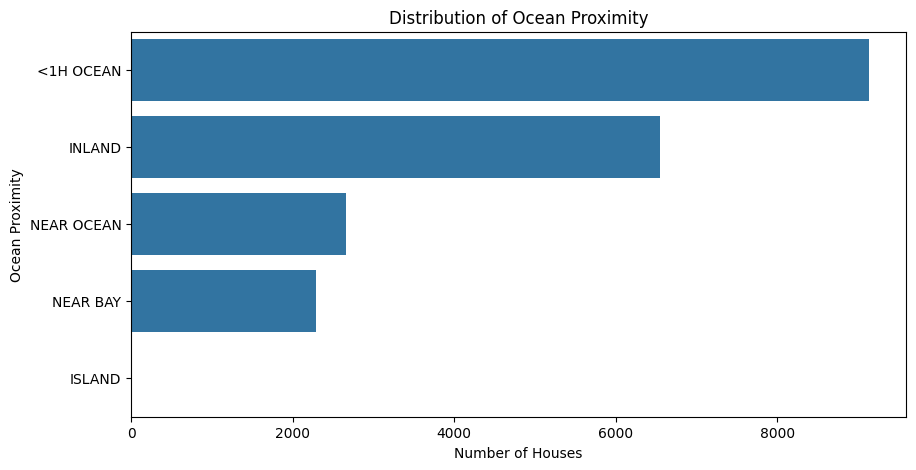

In [16]:
# # Target distribution: which drinks are most common?
# plt.figure(figsize=(10, 5))
# sns.countplot(data=df, y="coffee_name", order=df["coffee_name"].value_counts().index)
# plt.title("Distribution of Coffee Orders")
# plt.xlabel("Number of Orders")
# plt.ylabel("Coffee Name")
# plt.show()

# Target distribution: which types of houses are most common (in terms of ocean proximity) in California?
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y="ocean_proximity", order=df["ocean_proximity"].value_counts().index)
plt.title("Distribution of Ocean Proximity")
plt.xlabel("Number of Houses")
plt.ylabel("Ocean Proximity")
plt.show()


# STEP 4: DATA CLEANING / PREPROCESSING

Data Cleaning makes the dataset more consistent and structured in a way such that the model can easily use it to make predictions. This is where we handle missing values, duplicates, inconsistent data types, and extreme values. 

1. Duplicates 
2. Data Types
3. Extreme Values 
4. Missing Values 

Pro tip: If we don't want to risk tarnishing the original dataset or if we want to rexplore something from a column we may have already dropped, it's best to make a cleaned copy of your DataFrame. 

In [17]:
cleaned_df = df.copy()
print("Original Shape:", cleaned_df.shape)
print("Duplicate Rows:", cleaned_df.duplicated().sum())

#let's make sure to drop duplicates if any so the model doesn't see the same data twice and get confused 
cleaned_df = cleaned_df.drop_duplicates()
print("New Shape (after dropping duplicates):", cleaned_df.shape)

Original Shape: (20640, 10)
Duplicate Rows: 0


New Shape (after dropping duplicates): (20640, 10)


In [18]:
# #convert date and datetime cols --> actual datetime objects (not strings)
# cleaned_df["date"] = pd.to_datetime(cleaned_df["date"])
# cleaned_df["datetime"] = pd.to_datetime(cleaned_df["datetime"])
# cleaned_df[['date', 'datetime']].head()

In [19]:
# #check for any impossible/extreme values 
# #for example for the money column a negative value would be impossible 
# print("Rows with missing datetime: ", cleaned_df["datetime"].isnull().sum())
# print("Rows with missing date: ", cleaned_df["date"].isnull().sum())
# print("Rows with negative money: ", (cleaned_df['money'] <= 0).sum())

# # we want to keep only rows with valid datetime and positive money 
# cleaned_df = cleaned_df.dropna(subset=["datetime", "date"])
# cleaned_df = cleaned_df[cleaned_df['money'] > 0]
# cleaned_df.shape

#check for any impossible/extreme values 
print("Rows with missing median_house_value: ", cleaned_df["median_house_value"].isnull().sum())
print("Rows with negative median_house_value: ", (cleaned_df['median_house_value'] <= 0).sum())
print("Rows with missing total_bedrooms: ", cleaned_df["total_bedrooms"].isnull().sum())
print("Rows with negative total_bedrooms: ", (cleaned_df['total_bedrooms'] <= 0).sum())
print("Rows with missing total_rooms: ", cleaned_df["total_rooms"].isnull().sum())
print("Rows with negative total_rooms: ", (cleaned_df['total_rooms'] <= 0).sum())

cleaned_df = cleaned_df[cleaned_df['median_house_value'] > 0]
cleaned_df = cleaned_df[cleaned_df['total_bedrooms'] > 0]
cleaned_df = cleaned_df[cleaned_df['total_rooms'] > 0]
cleaned_df.shape

Rows with missing median_house_value:  0
Rows with negative median_house_value:  0
Rows with missing total_bedrooms:  207
Rows with negative total_bedrooms:  0
Rows with missing total_rooms:  0
Rows with negative total_rooms:  0


(20433, 10)

In [20]:
# # we can't train a model on data that isn't there, let's handle the missing values
# target_col = "coffee_name" 
# print("Missing values before handling:", cleaned_df[target_col].isnull().sum())
# cleaned_df = cleaned_df.dropna(subset=[target_col]) # drop rows where target variable is missing (can't train on those)
# print("Missing values after handling:", cleaned_df[target_col].isnull().sum())
# print("Cleaned shape: ", cleaned_df.shape)

# we can't train a model on data that isn't there, let's handle the missing values
target_col = "median_house_value" 
print("Missing values before handling:", cleaned_df[target_col].isnull().sum())
cleaned_df = cleaned_df.dropna(subset=[target_col]) # drop rows where target variable is missing (can't train on those)
print("Missing values after handling:", cleaned_df[target_col].isnull().sum())
print("Cleaned shape: ", cleaned_df.shape)

Missing values before handling: 0
Missing values after handling: 0
Cleaned shape:  (20433, 10)


In [21]:
# #for our columns with strings as values, make sure the format is standardized (ie latte vs Latte --> standardize those)
# for col in ['cash_type', 'coffee_name']:
#     cleaned_df[col] = cleaned_df[col].astype(str).str.strip().str.lower()

# cleaned_df[['cash_type', 'coffee_name']].head()

# STEP 5: FEATURE ENGINEERING 
When we say "feature engineering", features are our variables (ie. our columns) and engineering those means transforming them in a way such that we can derive patterns from the data. What that entails in the scope of machine learning is that the input variables for the model should be formatted in order for the model to understand them the way a human does, so we are converting our columns to useful features by doing that. 

In [22]:
# model_df = cleaned_df.copy()

# model_df["hour"] = model_df["datetime"].dt.hour
# model_df["day_of_week"] = model_df["datetime"].dt.day_name()
# model_df["day_of_week_num"] = model_df["datetime"].dt.dayofweek
# model_df["month"] = model_df["datetime"].dt.month
# model_df["day_of_month"] = model_df["datetime"].dt.day
# model_df["is_weekend"] = (model_df["datetime"].dt.dayofweek >= 5).astype(int)

# def get_time_of_day(hour):
#     if 5 <= hour < 12:
#         return "morning"
#     elif 12 <= hour < 17:
#         return "afternoon"
#     elif 17 <= hour < 21:
#         return "evening"
#     else:
#         return "night"

# model_df["time_of_day"] = model_df["hour"].apply(get_time_of_day)

# # cyclical time features: helps model understand that 23:00 and 0:00 are close
# model_df["hour_sin"] = np.sin(2 * np.pi * model_df["hour"] / 24)
# model_df["hour_cos"] = np.cos(2 * np.pi * model_df["hour"] / 24)

# model_df["month_sin"] = np.sin(2 * np.pi * model_df["month"] / 12)
# model_df["month_cos"] = np.cos(2 * np.pi * model_df["month"] / 12)

# model_df.head() 

model_df = cleaned_df.copy()

# Create household-level ratio features from the housing data
model_df["rooms_per_household"] = (
    model_df["total_rooms"] / model_df["households"].replace(0, np.nan)
)
model_df["bedrooms_per_room"] = (
    model_df["total_bedrooms"] / model_df["total_rooms"].replace(0, np.nan)
)
model_df["population_per_household"] = (
    model_df["population"] / model_df["households"].replace(0, np.nan)
)

# Add a log transform for income to reduce skew
model_df["log_median_income"] = np.log1p(model_df["median_income"])

model_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,log_median_income
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,2.232720
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,2.230165
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,2.111110
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,1.893579
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,1.578195


Let's quickly visualize how the new features we created relate to the target variable (coffee_name) to see if they might be useful for our model:

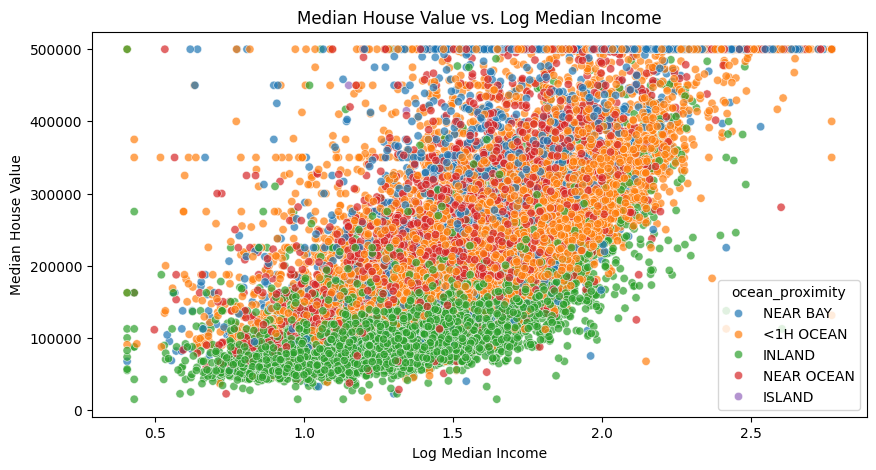

In [23]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=model_df,
    x="log_median_income",
    y="median_house_value",
    hue="ocean_proximity",
    alpha=0.7
)
plt.title("Median House Value vs. Log Median Income")
plt.xlabel("Log Median Income")
plt.ylabel("Median House Value")
plt.show()

# STEP 5.5: FEATURE SELECTION 
Here, our main goal is to just choose the columns that the model will be using. We want to avoid using columns that are overly specific like unique identifier columns, columns that are unavailable at the time of prediction, or columns that are too similar to the actual target. 

In [24]:
numeric_features = [
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "log_median_income"
]

categorical_features = [
    "ocean_proximity"
]

features = numeric_features + categorical_features

X = model_df[features]
y = model_df[target_col]

print("Feature columns:", features)
print("Target column:", target_col)
print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

Feature columns: ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'log_median_income', 'ocean_proximity']
Target column: median_house_value
X shape: (20433, 11)
y shape: (20433,)


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,log_median_income,ocean_proximity
0,41.0,880.0,129.0,322.0,126.0,8.3252,6.984127,0.146591,2.555556,2.232720,NEAR BAY
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,6.238137,0.155797,2.109842,2.230165,NEAR BAY
2,52.0,1467.0,190.0,496.0,177.0,7.2574,8.288136,0.129516,2.802260,2.111110,NEAR BAY
3,52.0,1274.0,235.0,558.0,219.0,5.6431,5.817352,0.184458,2.547945,1.893579,NEAR BAY
4,52.0,1627.0,280.0,565.0,259.0,3.8462,6.281853,0.172096,2.181467,1.578195,NEAR BAY


# STEP 6: TRAIN / TEST SPLIT 
Our model needs to be trained on data in order to learn the patterns that exist within it and once we've created our model, we test it with examples of data that it hasn't seen before. In order to do this, we must split our data into "training" and "testing" data, where the training set teaches the model and the testing set estimates how the model will perform on real world / new data. The code for doing this is pretty standardized, a good practice is the 80/20 split (train/test). (Note: don't worry too much about random state, this is something we can leave to abstraction for building ML models)

In [25]:
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("Training target summary:")
print(y_train.describe().round(2))

Training rows: 16346
Testing rows: 4087
Training target summary:
count     16346.00
mean     206644.40
std      115055.15
min       14999.00
25%      119300.00
50%      180100.00
75%      263800.00
max      500001.00
Name: median_house_value, dtype: float64


# STEP 7: MODEL SELECTION 
We will break this step down a little further into the following: 
1. Preprocessing Pipeline 
2. Establishing a Baseline Model 
3. Model Selection and Training 

### Why does preprocessing matter? 

Raw data is almost never ready for a model to learn from, thus not ready for actual machine learning, which requires numbers. Real datasets often contain one or many of the following which make it unusable to the model: 

- missing values
- text categories
- columns on different scales 
- messy labels 
- irrelevant columns 
- dates 

Preprocessing is the step where we turn the real world data that you'd be given into a format that a machine can more easily read and understand. Here, you'll see we use a 'ColumnTransformer' because different column types need different treatments. 

### What is a pipeline and why does it matter? 

A pipeline essentially means chaining multiple steps together, instead of doing them manually. Here we can put the following into one object: 

1. cleaning data 
2. encoding categories 
3. scaling numbers 
4. training the model

## Preprocessing Pipeline 

We know that machine learning models rely on inputs being quantitative, thus this step of creating a preprocessing pipeline handles both categorial and numeric features. 

1. Numeric features --> fill any missing values left and scale them 
2. Categorical features --> fill any missing values and one-hot encode them 

Question: We know that models need numeric variables so turning categorical features into those is what we call one-hot encoding. Identify a few examples of what columns could be one-hot encoded and HOW to one-hot encode different types of data. 

ANSWER: We should one-hot encode categorical features. In this case, we could one-hot encode day_of_week, time_of_day, and cash_type. To one-hot encode this data, we can use OneHotEncoder from sklearn.preprocessing.

Here, we want to fit preprocessing on the training data only, then apply it to the testing data after. 

**Important Key Terms to Know:** 

imputing: filling missing values with other values in the data (ie filling nan with mean/mode/median)

StandardScalar() --> preprocessing tool from Pipeline to scale numeric variables 

ColumnTransformer() --> does exactly what it sounds like, transforms columns 

OneHotEncoder() --> same thing, one-hot encodes columns 

In [26]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Baseline Model 

Before we train a real model, we want to build a simple baseline to see what a very basic prediction looks like. A good regression baseline is often just the mean house value in the training data. That gives us a reference point for whether more complex models are actually improving performance.

In [27]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_mae = mean_absolute_error(y_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_preds))
baseline_r2 = r2_score(y_test, baseline_preds)

print("Baseline MAE:", round(baseline_mae, 3))
print("Baseline RMSE:", round(baseline_rmse, 3))
print("Baseline R^2:", round(baseline_r2, 3))

Baseline MAE: 92836.501
Baseline RMSE: 116946.102
Baseline R^2: -0.0


## Model Selection and Training 

Here, we will compare several regression models to see which one best captures the relationship between housing features and median house value. 

1. Linear Regression: simple and interpretable  
2. Decision Tree: captures nonlinear relationships  
3. Random Forest: ensemble of many trees, often stronger than a single tree  
4. Extra Trees, Gradient Boosting, and HistGradientBoosting: additional flexible alternatives

In [28]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_leaf=5
    ),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    
    "Hist Gradient Boosting": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    )
}

results = []
trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    trained_pipelines[name] = pipe
    results.append({
        "model": name,
        "test_r2": r2,
        "test_mae": mae,
        "test_rmse": rmse
    })

results_df = pd.DataFrame(results).sort_values("test_r2", ascending=False)
results_df

/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,model,test_r2,test_mae,test_rmse
5,Hist Gradient Boosting,0.748271,40612.939389,58672.302042
3,Extra Trees,0.741886,40753.769148,59411.776777
2,Random Forest,0.741194,40912.728581,59491.361059
4,Gradient Boosting,0.728844,42634.144088,60894.228026
1,Decision Tree,0.691332,45294.346202,64969.919518
0,Linear Regression,0.642109,50584.741678,69958.729910


### Why compare multiple models? 

There is no sinlge best model for each dataset, different models typically learn different patterns in different ways:

Logistic Regression --> learns most linear relationships 
Decision Trees --> learn rule-based splits 
Random Forests --> combine many trees 
Extra Trees --> more randomness 
GRadient Boosting --> builds trees sequentially to fix previous mistakes 

In [29]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: Hist Gradient Boosting


# STEP 8: MODEL EVALUATION 
This is where we see how well the model performs and where it is making larger mistakes. For regression, metrics like R^2, MAE, and RMSE are more informative than a confusion matrix because the target is continuous.

In [30]:
test_preds = best_model.predict(X_test)

print("Test R^2:", round(r2_score(y_test, test_preds), 3))
print("Test MAE:", round(mean_absolute_error(y_test, test_preds), 3))
print("Test RMSE:", round(np.sqrt(mean_squared_error(y_test, test_preds)), 3))

Test R^2: 0.748
Test MAE: 40612.939
Test RMSE: 58672.302


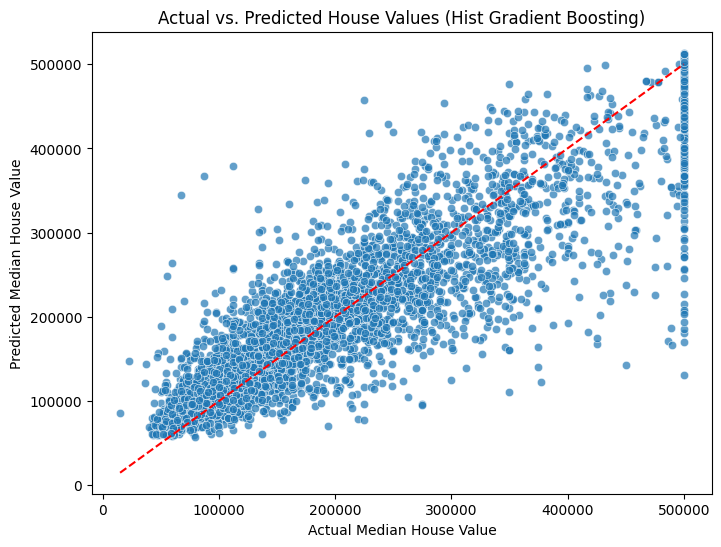

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=test_preds, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f"Actual vs. Predicted House Values ({best_model_name})")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.show()

## Cross-Validation

Cross-Validation gives us a more reliable estimate by training and testing the model several times on different splits of the data. 

5-fold cross-validation:
1. split data into 5 parts 
2. train on 4 parts 
3. test on remaining part 
4. repeat 5 times 
5. average the scores 

### Why one train/test split isn't enough: 

One train/test split can be lucky or unlucky. Cross-validation trains and evaluates the model multiple times on different splits to get a more stable performance estimate.

In [32]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2", n_jobs=-1)
    
    cv_results.append({
        "model": name,
        "mean_cv_r2": scores.mean(),
        "std_cv_r2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("mean_cv_r2", ascending=False)
cv_results_df

/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/elyse/Library/Python/3.13/lib/python/site-packages/sklearn/linear_model/_base.py:280: Runti

,model,mean_cv_r2,std_cv_r2
5,Hist Gradient Boosting,0.746367,0.013509
3,Extra Trees,0.742249,0.014202
2,Random Forest,0.741643,0.015080
4,Gradient Boosting,0.730666,0.010831
1,Decision Tree,0.688306,0.019174
0,Linear Regression,0.638679,0.010414


# Hyperparameter Tuning

A model has two types of settings: 
1. Parameters: these are learned from the data ie. the splits inside a decision tree 

2. Hyperparameters: these settings we choose before training. Grid search tries combinations of settings and uses cross-validation to find the best one.

Examples: 
- number of trees 
- max tree depth 
- minimum samples per leaf 
- max number of features considered at each split 

In [38]:
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid=param_grid,
    cv=4,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R^2:", round(grid_search.best_score_, 3))

final_model = grid_search.best_estimator_

Best parameters: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 300}
Best CV R^2: 0.74


In [40]:
final_preds = final_model.predict(X_test)

print("Final tuned model R^2:", round(r2_score(y_test, final_preds), 3))
print("Final tuned model MAE:", round(mean_absolute_error(y_test, final_preds), 3))
print("Final tuned model RMSE:", round(np.sqrt(mean_squared_error(y_test, final_preds)), 3))

Final tuned model R^2: 0.746
Final tuned model MAE: 41015.507
Final tuned model RMSE: 58945.848


## Model Interpretability 

A model's R^2 tells us how much variance it explains, while feature importance helps us understand which variables were most useful for making predictions. For tree-based models, feature importance estimates which inputs contributed most to the final predictions.

In [41]:
#let's get our feature names from the preprocessor and coefficients from 
#the logistic regression model to see which features are most 
# important for predicting each drink

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
importances = final_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
5,num__median_income,0.212559
9,num__log_median_income,0.211926
11,cat__ocean_proximity_INLAND,0.118847
8,num__population_per_household,0.102053
7,num__bedrooms_per_room,0.075751
6,num__rooms_per_household,0.062505
0,num__housing_median_age,0.053701
3,num__population,0.031422
1,num__total_rooms,0.029236
10,cat__ocean_proximity_<1H OCEAN,0.027319


## Error Analysis 

R^2 and MAE tell us how accurate the model is overall, while error analysis helps us identify where the model is making its biggest mistakes. This step is especially useful when we want to understand which neighborhoods are being overpredicted or underpredicted.

In [42]:
errors = X_test.copy()
errors["actual"] = y_test.values
errors["predicted"] = final_preds
errors["residual"] = errors["actual"] - errors["predicted"]

errors = errors.sort_values("residual", key=lambda s: s.abs(), ascending=False)
errors.head(20)

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,log_median_income,ocean_proximity,actual,predicted,residual
10448,22.0,2728.0,616.0,1081.0,566.0,1.6393,4.819788,0.225806,1.909894,0.970514,<1H OCEAN,500001.0,142561.269242,357439.730758
12069,6.0,502.0,76.0,228.0,65.0,4.2386,7.723077,0.151394,3.507692,1.656054,INLAND,500001.0,162832.592486,337168.407514
4823,26.0,1809.0,640.0,2543.0,640.0,2.3536,2.826563,0.353787,3.973438,1.210034,<1H OCEAN,500000.0,172593.291346,327406.708654
6376,43.0,1694.0,283.0,674.0,267.0,4.1797,6.344569,0.167060,2.524345,1.644747,INLAND,486800.0,161916.735430,324883.264570
15624,52.0,812.0,252.0,629.0,247.0,2.5875,3.287449,0.310345,2.546559,1.277456,NEAR BAY,500001.0,190033.071260,309967.928740
489,48.0,2153.0,517.0,1656.0,459.0,3.0417,4.690632,0.240130,3.607843,1.396665,NEAR BAY,489600.0,180021.832970,309578.167030
4009,31.0,1950.0,383.0,870.0,357.0,3.1875,5.462185,0.196410,2.436975,1.432104,<1H OCEAN,500001.0,193548.534643,306452.465357
12138,16.0,56.0,7.0,39.0,14.0,2.6250,4.000000,0.125000,2.785714,1.287854,INLAND,500001.0,204883.908610,295117.091390
5354,33.0,1730.0,386.0,994.0,363.0,3.7277,4.765840,0.223121,2.738292,1.553439,<1H OCEAN,500001.0,210066.853840,289934.146160
10616,5.0,1256.0,256.0,880.0,288.0,2.4233,4.361111,0.203822,3.055556,1.230605,<1H OCEAN,450000.0,165003.454654,284996.545346


## Congrats! 

By this point you have completed the full machine learning workflow end to end. You loaded a dataset, cleaned it, engineered features, trained several models, evaluated them, and interpreted the results. The next step would be to turn these findings into a stakeholder-friendly takeaway, such as which housing characteristics most strongly influence estimated property values.

Knowing this information, a real-estate team or housing analyst could use the model to better estimate property values, understand which variables matter most, and prioritize features that improve valuation workflows. Overall, these insights can be valuable for planning, pricing, and forecasting.